In [2]:
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

In [3]:
PROJECT_ROOT = Path.cwd().parent

DATASET = PROJECT_ROOT / "backend/app/datasets/matching_dataset.csv"

MODEL = PROJECT_ROOT / "backend/app/models/xgboost_model.pkl"

FEATURES = PROJECT_ROOT / "backend/app/models/feature_columns.pkl"

In [4]:
df = pd.read_csv(DATASET)

model = joblib.load(MODEL)

feature_columns = joblib.load(FEATURES)

print(feature_columns)

['matched_skill_count', 'missing_skill_count', 'resume_skill_count', 'job_skill_count', 'skill_overlap_ratio', 'experience_gap', 'education_gap', 'project_match_count', 'certification_match_count', 'retrieval_score', 'title_similarity', 'keyword_similarity', 'technical_job_score']


In [5]:
X = df[feature_columns]

y = df["label"]

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    stratify=y,

    random_state=42

)

In [7]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [8]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision :", precision_score(y_test, y_pred))

print("Recall :", recall_score(y_test, y_pred))

print("F1 :", f1_score(y_test, y_pred))

print("ROC AUC :", roc_auc_score(y_test, y_prob))

print()

print(classification_report(y_test, y_pred))

Accuracy : 0.997
Precision : 0.9979959919839679
Recall : 0.996
F1 : 0.996996996996997
ROC AUC : 0.999704

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       500

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



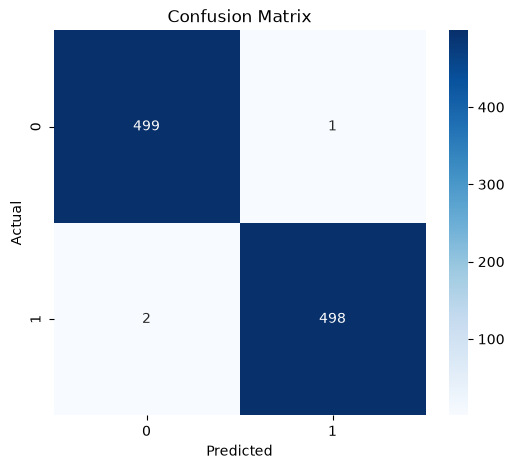

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

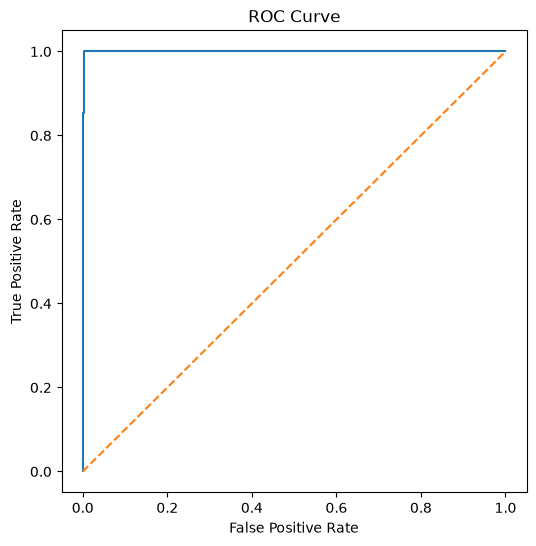

In [10]:
fpr, tpr, _ = roc_curve(

    y_test,

    y_prob

)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

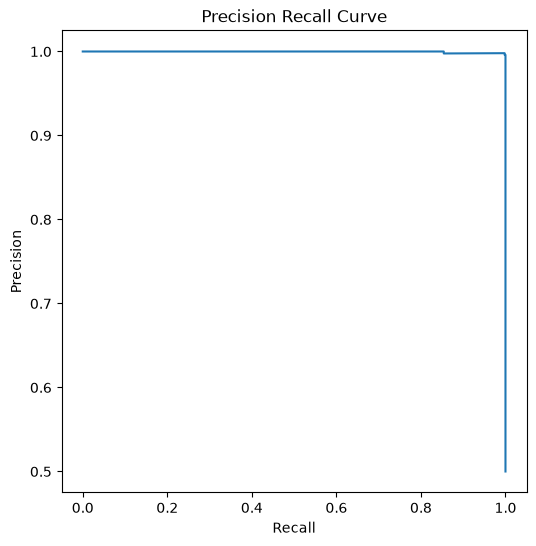

In [11]:
precision, recall, _ = precision_recall_curve(

    y_test,

    y_prob

)

plt.figure(figsize=(6,6))

plt.plot(

    recall,

    precision

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve")

plt.show()

,Feature,Importance
9,retrieval_score,0.305889
0,matched_skill_count,0.223028
5,experience_gap,0.153640
4,skill_overlap_ratio,0.117684
1,missing_skill_count,0.045620
3,job_skill_count,0.039581
7,project_match_count,0.032648
6,education_gap,0.025839
11,keyword_similarity,0.024433
10,title_similarity,0.022475


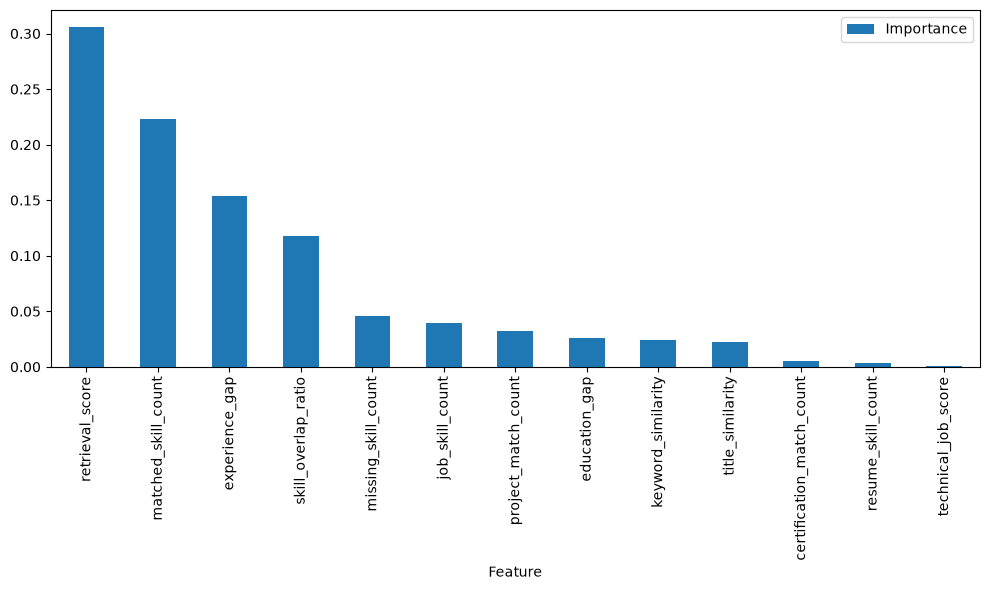

In [12]:
importance = pd.DataFrame(

    {

        "Feature": feature_columns,

        "Importance": model.feature_importances_

    }

)

importance = importance.sort_values(

    "Importance",

    ascending=False

)

display(importance)

importance.plot.bar(

    x="Feature",

    y="Importance",

    figsize=(10,6)

)

plt.tight_layout()

plt.show()

In [13]:
results = X_test.copy()

results["Actual"] = y_test.values

results["Prediction"] = y_pred

results["Probability"] = y_prob

errors = results[

    results["Actual"] != results["Prediction"]

]

display(errors.head(20))

,matched_skill_count,missing_skill_count,resume_skill_count,job_skill_count,skill_overlap_ratio,experience_gap,education_gap,project_match_count,certification_match_count,retrieval_score,title_similarity,keyword_similarity,technical_job_score,Actual,Prediction,Probability
3820,4,5,14,9,0.4444,0,3,2,0,0.4191,0.5000,0.0480,28.0,0,1,0.998671
3603,1,1,12,2,0.5000,0,0,0,0,0.4508,0.0000,0.0154,20.0,1,0,0.426610
4008,1,9,1,10,0.1000,0,0,0,0,0.3636,0.1667,0.0057,36.0,1,0,0.158515


In [14]:
summary = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "ROC AUC"

    ],

    "Value":[

        accuracy_score(y_test,y_pred),

        precision_score(y_test,y_pred),

        recall_score(y_test,y_pred),

        f1_score(y_test,y_pred),

        roc_auc_score(y_test,y_prob)

    ]

})

display(summary)

,Metric,Value
0,Accuracy,0.997000
1,Precision,0.997996
2,Recall,0.996000
3,F1,0.996997
4,ROC AUC,0.999704


In [15]:
# Final Model Assessment

print("=" * 70)
print("RecruitIQ Model Evaluation Summary")
print("=" * 70)

summary = {
    "Dataset Rows": len(df),
    "Features Used": len(feature_columns),
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall": round(recall_score(y_test, y_pred), 4),
    "F1 Score": round(f1_score(y_test, y_pred), 4),
    "ROC AUC": round(roc_auc_score(y_test, y_prob), 4),
}

for key, value in summary.items():
    print(f"{key:<20}: {value}")

print("\nModel Status : READY FOR DEPLOYMENT")

RecruitIQ Model Evaluation Summary
Dataset Rows        : 5000
Features Used       : 13
Accuracy            : 0.997
Precision           : 0.998
Recall              : 0.996
F1 Score            : 0.997
ROC AUC             : 0.9997

Model Status : READY FOR DEPLOYMENT
